***INSTALL AND IMPORTS***

In [5]:
!pip install yfinance yahoofinancials -q
import numpy as np
import pandas as pd
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded.")

All libraries loaded.


***EXTRACT TICKETERS***

In [7]:
import requests
import io

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
response = requests.get(url, headers=headers)
sp500_table = pd.read_html(io.StringIO(response.text))[0]

tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
sector_map = sp500_table[['Symbol','Security','GICS Sector']].copy()
sector_map['Symbol'] = sector_map['Symbol'].str.replace('.', '-', regex=False)

print(f"Total tickers extracted: {len(tickers)}")
print(f"\nFull ticker list:\n{tickers}")

Total tickers extracted: 503

Full ticker list:
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CASY', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CIEN', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COHR', 'COIN', 'CL', 'CMCSA', 'FIX', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CT

***LOAD DATA***

In [9]:
START_DATE = '2022-01-01'
END_DATE   = '2025-01-01'
print("Downloading data... takes 3-5 mins")
p = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True, progress=True)
prices = p['Close']

try:
    yahoo_fin = YahooFinancials('AAPL')
    hist_data = yahoo_fin.get_historical_price_data('2022-01-01', '2022-01-10', 'daily')
    aapl_data = hist_data['AAPL']
    price_list = aapl_data.get('prices', aapl_data.get('eventsData', []))
    print("\nYahooFinancials sample (AAPL):")
    for day in price_list[:3]:
        print(f"  {day.get('formatted_date','N/A')} | Close: {day.get('close', 'N/A')}")
except Exception as e:
    print(f"\nYahooFinancials note: {e} — yfinance data loaded successfully above.")

print(f"\nShape: {prices.shape}")
print(f"Rows (trading days): {prices.shape[0]}")
print(f"Columns (stocks): {prices.shape[1]}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")

[                       0%                       ]

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')



YahooFinancials sample (AAPL):

YahooFinancials note: slice(None, 3, None) — yfinance data loaded successfully above.

Shape: (753, 503)
Rows (trading days): 753
Columns (stocks): 503
Date range: 2022-01-03 to 2024-12-31


***CLEAN DATA***

In [10]:
print(f"BEFORE: Shape={prices.shape}, Missing={prices.isna().sum().sum()}")
min_obs = int(0.90 * len(prices))
prices_clean = prices.dropna(axis=1, thresh=min_obs).ffill().bfill()
prices_clean = prices_clean.loc[:, (prices_clean > 0).all()]
print(f"AFTER:  Shape={prices_clean.shape}, Missing={prices_clean.isna().sum().sum()}")
print(f"Stocks removed: {prices.shape[1] - prices_clean.shape[1]}")

BEFORE: Shape=(753, 503), Missing=3651
AFTER:  Shape=(753, 496), Missing=0
Stocks removed: 7


***DAILY RETURN***

In [11]:
daily_returns = prices_clean.pct_change().dropna()
print(f"Daily returns shape: {daily_returns.shape}")
print(f"Mean daily return (avg across all stocks): {daily_returns.mean().mean()*100:.4f}%")
print(f"\nSample daily returns (first 5 stocks, 5 days):")
print(daily_returns.iloc[:5,:5].applymap(lambda x: f"{x*100:.4f}%"))

Daily returns shape: (752, 496)
Mean daily return (avg across all stocks): 0.0441%

Sample daily returns (first 5 stocks, 5 days):
Ticker             A      AAPL      ABBV      ABNB       ABT
Date                                                        
2022-01-04  -3.3806%  -1.2692%  -0.1920%  -1.0887%  -2.3518%
2022-01-05  -1.7131%  -2.6600%   0.5253%  -5.0059%  -0.4493%
2022-01-06   0.3499%  -1.6693%  -0.4710%  -1.5408%  -0.0148%
2022-01-07  -2.6623%   0.0988%  -0.2588%   3.9437%   0.3108%
2022-01-10   0.0069%   0.0116%   1.1195%  -3.2159%  -0.2213%


***BETA***

In [13]:
sp500_index = yf.download('^GSPC', start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)['Close']

if isinstance(sp500_index, pd.DataFrame):
    sp500_index = sp500_index.squeeze()

index_returns = sp500_index.pct_change().dropna()
aligned_stocks, aligned_index = daily_returns.align(index_returns, join='inner', axis=0)

if isinstance(aligned_index, pd.DataFrame):
    aligned_index = aligned_index.squeeze()

index_std = aligned_index.std()
beta_dict = {}
for ticker in aligned_stocks.columns:
    corr = aligned_stocks[ticker].corr(aligned_index)
    beta_dict[ticker] = corr * (aligned_stocks[ticker].std() / index_std)

beta_series = pd.Series(beta_dict, name='Beta').sort_values()
print(f"Stocks computed: {len(beta_series)}")
print(f"Mean Beta: {beta_series.mean():.4f}")
print(f"Min: {beta_series.min():.4f} ({beta_series.idxmin()})")
print(f"Max: {beta_series.max():.4f} ({beta_series.idxmax()})")
print(f"\nFull Beta list:\n{beta_series.to_string()}")

Stocks computed: 496
Mean Beta: 0.9437
Min: 0.1332 (GIS)
Max: 3.2941 (CVNA)

Full Beta list:
GIS      0.133249
CPB      0.133665
SJM      0.196589
HRL      0.236607
LMT      0.243865
JNJ      0.246610
KHC      0.249739
MRK      0.258821
HSY      0.271795
CAG      0.275951
NOC      0.276418
BMY      0.280252
MCK      0.288921
KMB      0.291022
CHD      0.295730
ABBV     0.299098
CBOE     0.304139
CL       0.307811
KR       0.312664
MO       0.316702
ED       0.320257
VZ       0.324779
DUK      0.350796
COR      0.360913
CMS      0.368093
CLX      0.372093
PG       0.373093
SO       0.375872
KDP      0.376477
WEC      0.377766
T        0.379213
PEP      0.382882
CME      0.383688
D        0.386005
PM       0.388285
KO       0.389235
MKC      0.393500
XEL      0.395358
WMT      0.407970
HUM      0.408352
DTE      0.411799
LHX      0.417665
AEE      0.420491
CAH      0.420776
AEP      0.425264
AMGN     0.427130
WM       0.428810
PNW      0.430910
FE       0.431789
UNH      0.438062
ETR    

***ANNUAL VOLATILITY***

In [14]:
annual_vol = aligned_stocks.std() * np.sqrt(252)
annual_vol.name = 'Annual_Volatility'
print(f"Mean volatility: {annual_vol.mean()*100:.2f}%")
print(f"Min: {annual_vol.min()*100:.2f}% ({annual_vol.idxmin()})")
print(f"Max: {annual_vol.max()*100:.2f}% ({annual_vol.idxmax()})")
print(f"\nFull Annual Volatility list:")
print(annual_vol.sort_values().apply(lambda x: f"{x*100:.2f}%").to_string())

Mean volatility: 31.43%
Min: 15.62% (KO)
Max: 134.10% (CVNA)

Full Annual Volatility list:
Ticker
KO        15.62%
JNJ       16.38%
PEP       17.04%
MCD       17.35%
CL        17.37%
BRK-B     17.38%
PG        17.59%
RSG       17.80%
MDLZ      18.50%
KMB       18.56%
WM        18.77%
DUK       18.82%
KDP       18.87%
ED        18.94%
YUM       19.13%
ATO       19.32%
MRSH      19.34%
COR       19.51%
SO        19.61%
L         19.61%
PPL       19.71%
FE        19.77%
O         19.82%
GIS       19.84%
GD        19.96%
DTE       19.99%
CMS       20.01%
MRK       20.03%
WEC       20.12%
CME       20.20%
ROP       20.25%
MO        20.26%
EVRG      20.28%
CB        20.28%
CHD       20.29%
AEE       20.46%
WMT       20.63%
HON       20.65%
PM        20.75%
SRE       20.75%
BDX       20.82%
NI        20.91%
PEG       20.95%
LMT       20.95%
LNT       20.96%
AEP       21.00%
CNP       21.01%
ITW       21.06%
KHC       21.10%
STZ       21.21%
HSY       21.29%
IBM       21.32%
AJG       21.34%
D

***COMBINED DATAFRAME***

In [15]:
mean_daily_ret = aligned_stocks.mean()
mean_daily_ret.name = 'Daily_Return'
df = pd.concat([mean_daily_ret, beta_series, annual_vol], axis=1).dropna()
df.columns = ['Daily_Return', 'Beta', 'Annual_Volatility']
df = df.join(sector_map.set_index('Symbol')[['Security','GICS Sector']], how='left')
print(f"Final shape: {df.shape}")
print(df.describe())
df.to_csv('sp500_metrics.csv')
print("\nSaved to sp500_metrics.csv")
display(df.head(10))

Final shape: (496, 5)
       Daily_Return        Beta  Annual_Volatility
count    496.000000  496.000000         496.000000
mean       0.000441    0.943691           0.314300
std        0.000665    0.431838           0.114803
min       -0.001695    0.133249           0.156193
25%        0.000035    0.632986           0.240116
50%        0.000384    0.911692           0.285015
75%        0.000764    1.155699           0.357327
max        0.004106    3.294068           1.341039

Saved to sp500_metrics.csv


,Daily_Return,Beta,Annual_Volatility,Security,GICS Sector
A,-0.000002,1.024801,0.296259,Agilent Technologies,Health Care
AAPL,0.000591,1.210689,0.270935,Apple Inc.,Information Technology
ABBV,0.000610,0.299098,0.219958,AbbVie,Health Care
ABNB,0.000074,1.666256,0.467875,Airbnb,Consumer Discretionary
ABT,-0.000106,0.672317,0.217839,Abbott Laboratories,Health Care
ACGL,0.001165,0.569789,0.253997,Arch Capital Group,Financials
ACN,0.000011,1.094207,0.270331,Accenture,Information Technology
ADBE,-0.000022,1.447974,0.383083,Adobe Inc.,Information Technology
ADI,0.000514,1.339929,0.318058,Analog Devices,Information Technology
ADM,-0.000111,0.551200,0.294043,Archer Daniels Midland,Consumer Staples


***4 CHARTS***

CHART 1 DISTIBUTIONS

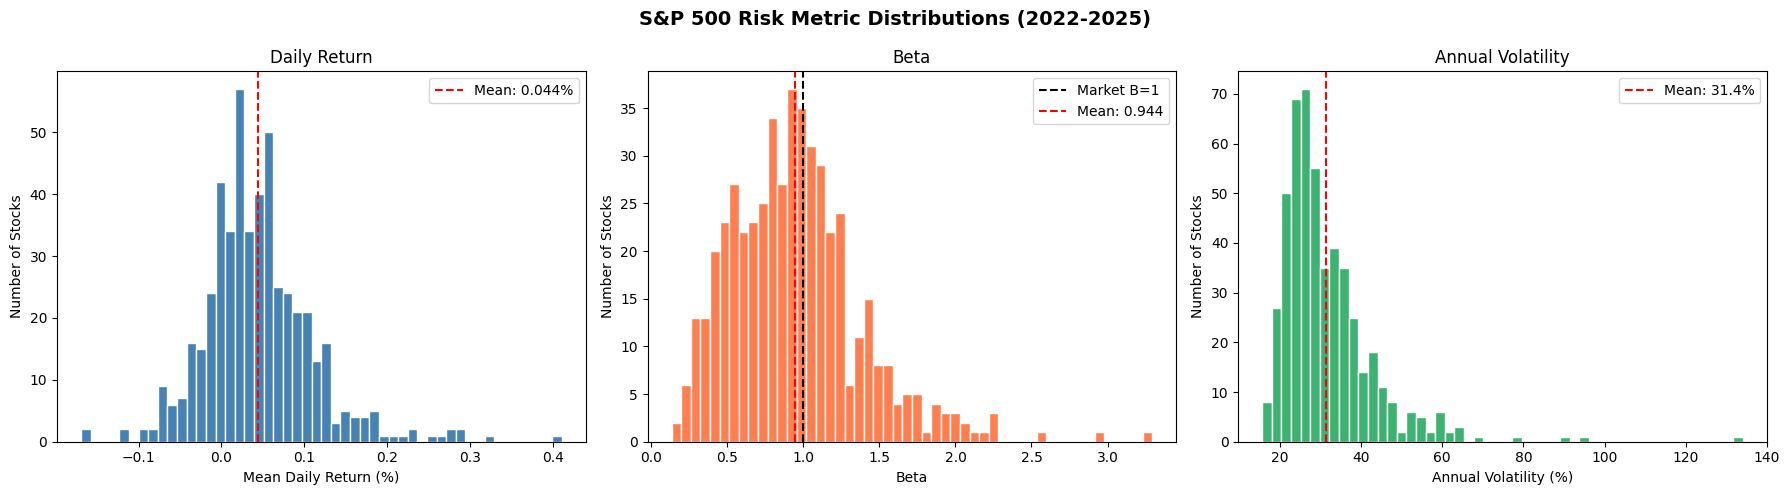

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('S&P 500 Risk Metric Distributions (2022-2025)', fontsize=14, fontweight='bold')
axes[0].hist(df['Daily_Return']*100, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['Daily_Return'].mean()*100, color='red', linestyle='--', label=f"Mean: {df['Daily_Return'].mean()*100:.3f}%")
axes[0].set_title('Daily Return'); axes[0].set_xlabel('Mean Daily Return (%)'); axes[0].set_ylabel('Number of Stocks'); axes[0].legend()
axes[1].hist(df['Beta'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(1, color='black', linestyle='--', linewidth=1.5, label='Market B=1')
axes[1].axvline(df['Beta'].mean(), color='red', linestyle='--', label=f"Mean: {df['Beta'].mean():.3f}")
axes[1].set_title('Beta'); axes[1].set_xlabel('Beta'); axes[1].set_ylabel('Number of Stocks'); axes[1].legend()
axes[2].hist(df['Annual_Volatility']*100, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].axvline(df['Annual_Volatility'].mean()*100, color='red', linestyle='--', label=f"Mean: {df['Annual_Volatility'].mean()*100:.1f}%")
axes[2].set_title('Annual Volatility'); axes[2].set_xlabel('Annual Volatility (%)'); axes[2].set_ylabel('Number of Stocks'); axes[2].legend()
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


CHART 2 SCATTER PLOTS


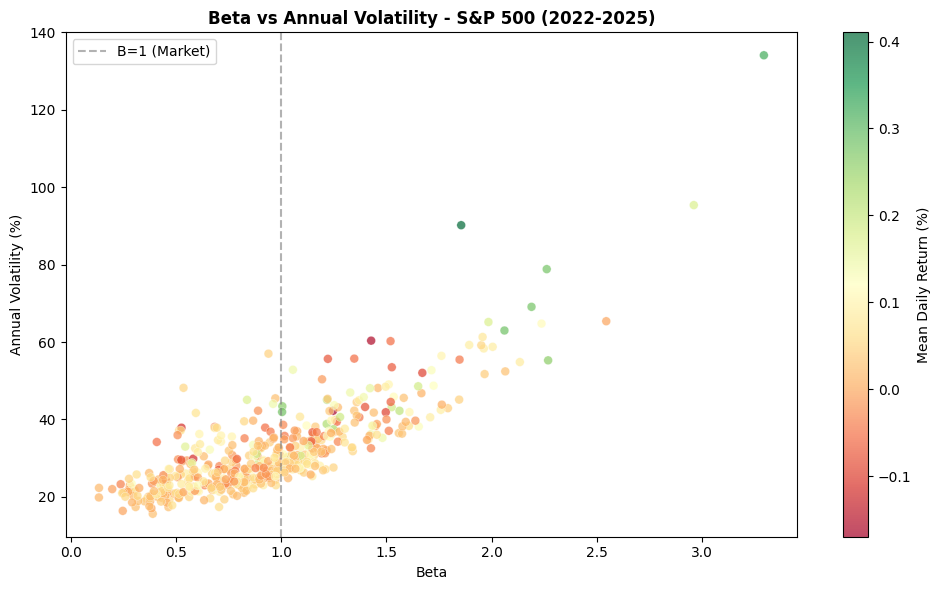

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['Beta'], df['Annual_Volatility']*100, c=df['Daily_Return']*100, cmap='RdYlGn', alpha=0.7, edgecolors='white', linewidth=0.3, s=40)
plt.colorbar(sc, label='Mean Daily Return (%)')
ax.axvline(1, color='grey', linestyle='--', alpha=0.6, label='B=1 (Market)')
ax.set_xlabel('Beta'); ax.set_ylabel('Annual Volatility (%)')
ax.set_title('Beta vs Annual Volatility - S&P 500 (2022-2025)', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('fig2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

CHART 3 SECTOR BOXPLOT

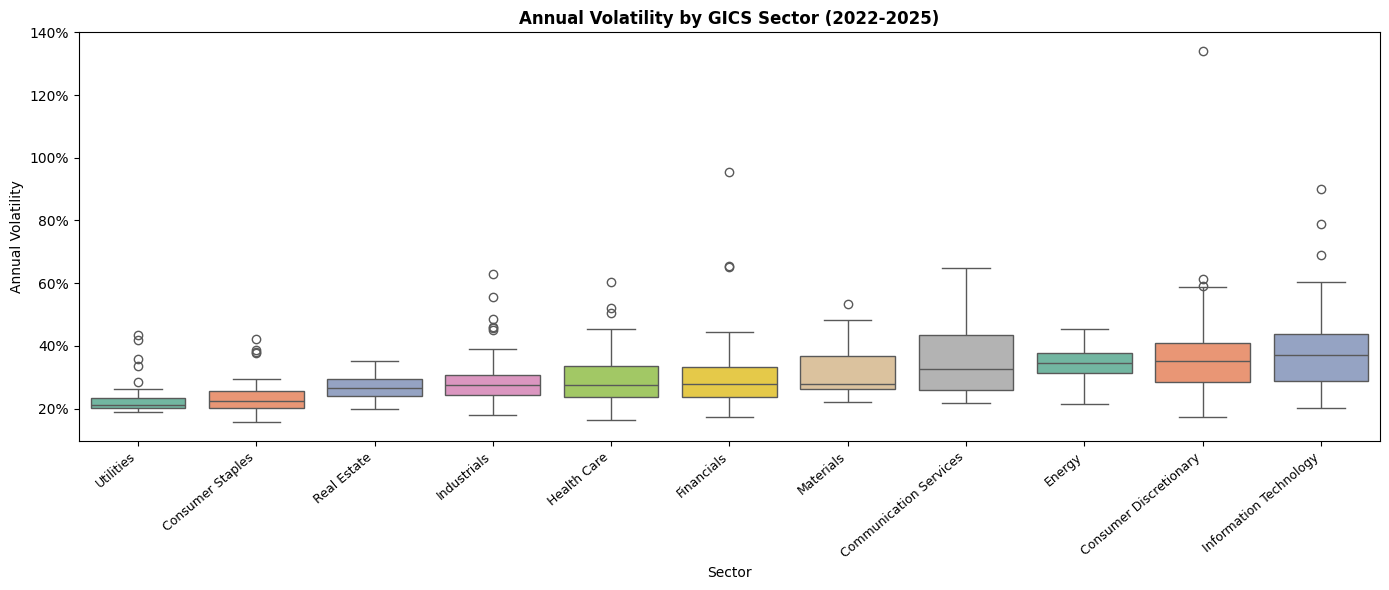

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('GICS Sector')['Annual_Volatility'].median().sort_values().index
sns.boxplot(data=df, x='GICS Sector', y='Annual_Volatility', order=order, palette='Set2', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Annual Volatility by GICS Sector (2022-2025)', fontweight='bold')
ax.set_xlabel('Sector'); ax.set_ylabel('Annual Volatility')
plt.tight_layout()
plt.savefig('fig3_sector.png', dpi=150, bbox_inches='tight')
plt.show()

CHART 4 EXTREME BETA

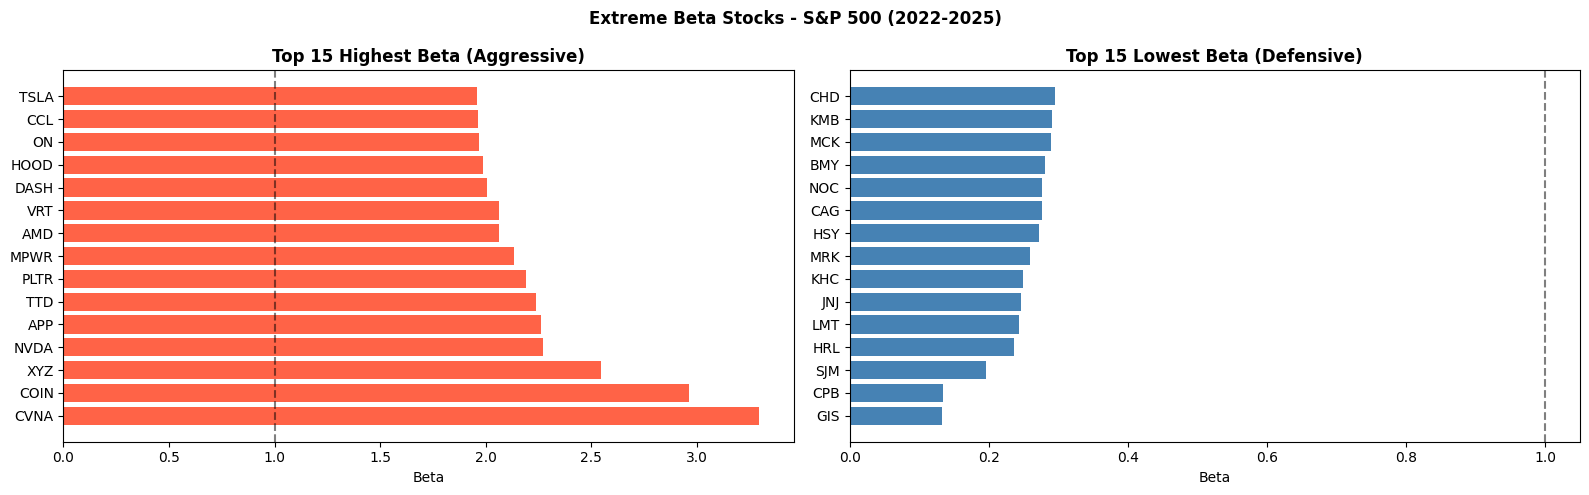

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top15 = beta_series.nlargest(15)
bottom15 = beta_series.nsmallest(15)
axes[0].barh(top15.index, top15.values, color='tomato')
axes[0].set_title('Top 15 Highest Beta (Aggressive)', fontweight='bold')
axes[0].set_xlabel('Beta'); axes[0].axvline(1, color='black', linestyle='--', alpha=0.5)
axes[1].barh(bottom15.index, bottom15.values, color='steelblue')
axes[1].set_title('Top 15 Lowest Beta (Defensive)', fontweight='bold')
axes[1].set_xlabel('Beta'); axes[1].axvline(1, color='black', linestyle='--', alpha=0.5)
plt.suptitle('Extreme Beta Stocks - S&P 500 (2022-2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_extreme_beta.png', dpi=150, bbox_inches='tight')
plt.show()